# Experiment 1

Overfit MAP prediction on exact torus longitudinalis traces.

In [1]:
import contextlib
import io
import os
import time

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import tensorstore as ts
import torch
from sbi.inference import NPE
from sbi.utils import BoxUniform
from torch.utils.tensorboard import SummaryWriter

import scienceplots

plt.style.use("science")
plt.rcParams["text.usetex"] = False

PATH = "/Users/s/vault/neural_data/janelia"
_ = torch.manual_seed(0)

In [2]:
subject_id = "06"

tr = ts.open({
    "open": True,
    "driver": "zarr3",
    "kvstore": f"file://{PATH}/ts_files/subject_{subject_id}_traces.zarr",
}).result()
co = ts.open({
    "open": True,
    "driver": "zarr3",
    "kvstore": f"file://{PATH}/ts_files/subject_{subject_id}_coordinates.zarr",
}).result().read().result().astype(int)

ref = scipy.io.loadmat(f"{PATH}/Additional_mat_files/ReferenceBrain.mat")["anat_stack_norm"]
with h5py.File(f"{PATH}/Additional_mat_files/MaskDatabase.mat") as f:
  jc = f["MaskDatabase"]["jc"][:].astype(int).ravel()
  v = f["MaskDatabase"]["ir"][jc[108]:jc[109]].astype(np.int64).ravel() - 1

m = np.zeros(ref.shape, bool)
m[v % ref.shape[0], (v // ref.shape[0]) % ref.shape[1], v // (ref.shape[0] * ref.shape[1])] = True
ix = np.flatnonzero(m[co[:, 0], co[:, 1], co[:, 2]])
a = tr[:, ix].read().result()

In [3]:
a.shape, a.min(), a.max(), a.mean(), a.std()

((3780, 197),
 np.float32(-0.080205865),
 np.float32(2.2078166),
 np.float32(0.1224679),
 np.float32(0.07949089))

## Activity buckets

Use the robust frame-to-frame scale as the equivalence width.

(0.02697473378771128, 86)

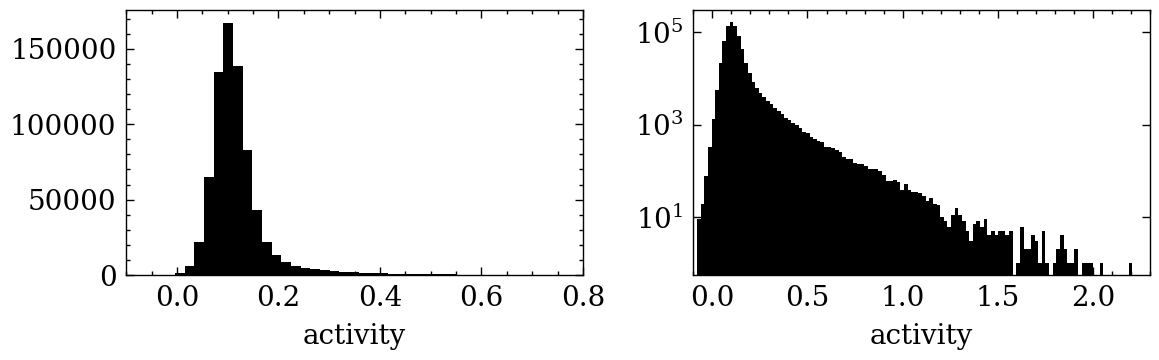

In [4]:
d = np.diff(a, axis=0).ravel()
w = float(1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2))
lo = np.floor(a.min() / w) * w
hi = np.ceil(a.max() / w) * w
grid = np.arange(lo, hi + w, w, dtype=np.float32)

fig, ax = plt.subplots(1, 2, figsize=(6, 2), dpi=200)
ax[0].hist(a.ravel(), bins=120, color="k")
ax[0].set_xlim(-0.1, 0.8)
ax[0].set_xlabel("activity")
ax[1].hist(a.ravel(), bins=120, color="k")
ax[1].set_yscale("log")
ax[1].set_xlim(-0.1, 2.3)
ax[1].set_xlabel("activity")
plt.tight_layout()
w, len(grid)

In [5]:
sel = a.mean(0) > 0.15
aa = a[:, sel]
c = 256
hs = (1, 16)
st = np.arange(0, len(aa) - c - max(hs) + 1, 10)
z = np.stack([aa[i:i+c] for i in st])
x = torch.tensor(z.transpose(0, 2, 1).reshape(-1, c), dtype=torch.float32)
ys = {
    h: torch.tensor(np.stack([aa[i+c+h-1] for i in st]).ravel()[:, None], dtype=torch.float32)
    for h in hs
}
aa.shape, x.shape, {h: y.shape for h, y in ys.items()}

((3780, 30),
 torch.Size([10530, 256]),
 {1: torch.Size([10530, 1]), 16: torch.Size([10530, 1])})

## Exact lookup ceiling

In [6]:
def bidx(v):
  return np.clip(np.rint((np.asarray(v) - lo) / w).astype(int), 0, len(grid) - 1)

def exact_map(x, y):
  xn = bidx(x.numpy()).astype(np.uint8)
  bn = bidx(y.numpy().ravel())
  tab = {}
  for r, b in zip(xn, bn):
    tab.setdefault(r.tobytes(), []).append(b)
  bp = np.array([np.bincount(tab[r.tobytes()]).argmax() for r in xn])
  return grid[bp], len(tab)

rows = []
for h in hs:
  y = ys[h].numpy().ravel()
  p, n = exact_map(x, ys[h])
  last = x[:, -1].numpy()
  rows += [
      {"h": h, "model": "exact", "mae": np.abs(p-y).mean(), "bucket_acc": (bidx(p) == bidx(y)).mean()},
      {"h": h, "model": "last", "mae": np.abs(last-y).mean(), "bucket_acc": (bidx(last) == bidx(y)).mean()},
  ]

n / len(x), pd.DataFrame(rows)

(1.0,
     h  model       mae  bucket_acc
 0   1  exact  0.006797    1.000000
 1   1   last  0.040677    0.224027
 2  16  exact  0.006780    1.000000
 3  16   last  0.103090    0.126306)

## NPE MAP

Train and score on the same contexts.

In [7]:
prior = BoxUniform(-0.25 * torch.ones(1), 3.0 * torch.ones(1))

def fit_npe(x, y):
  torch.manual_seed(0)
  inf = NPE(prior=prior, summary_writer=SummaryWriter(log_dir=f"/tmp/zapbench-sbi/{time.time_ns()}"))
  with contextlib.redirect_stdout(io.StringIO()):
    de = inf.append_simulations(y, x).train(
        training_batch_size=512, validation_fraction=0.01,
        stop_after_epochs=8, max_num_epochs=60, show_train_summary=False)
  opt = torch.optim.Adam(de.parameters(), lr=5e-4)
  dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x, y), batch_size=512, shuffle=True)
  loss = []
  for _ in range(100):
    z = []
    for xb, yb in dl:
      l = de.loss(yb, xb).mean()
      opt.zero_grad()
      l.backward()
      opt.step()
      z.append(l.item())
    loss.append(np.mean(z))
  return de, loss

def get_map(de, x):
  g = torch.tensor(grid[:, None, None])
  out = []
  with torch.no_grad():
    for xb in x.split(128):
      lp = de.log_prob(g.expand(-1, len(xb), -1), xb)
      out.append(grid[lp.argmax(0).numpy()])
  return np.concatenate(out)

In [8]:
des = {}
loss = {}
t0 = time.time()
for h in hs:
  des[h], loss[h] = fit_npe(x, ys[h])
time.time() - t0, {h: (v[0], v[-1]) for h, v in loss.items()}

/Users/s/miniconda3/envs/zapbench/lib/python3.11/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


/Users/s/miniconda3/envs/zapbench/lib/python3.11/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


(32.934425830841064,
 {1: (np.float64(-1.773248280797686), np.float64(-2.5432014351799372)),
  16: (np.float64(-0.9021317277635846), np.float64(-2.1588081405276345))})

In [9]:
maps = {}
for h in hs:
  y = ys[h].numpy().ravel()
  p = get_map(des[h], x)
  maps[h] = p
  rows.append({"h": h, "model": "npe", "mae": np.abs(p-y).mean(), "bucket_acc": (bidx(p) == bidx(y)).mean()})

res = pd.DataFrame(rows).sort_values(["h", "model"]).reset_index(drop=True)
res

,h,model,mae,bucket_acc
0,1,exact,0.006797,1.000000
1,1,last,0.040677,0.224027
2,1,npe,0.019940,0.491073
3,16,exact,0.006780,1.000000
4,16,last,0.103090,0.126306
5,16,npe,0.031273,0.396486


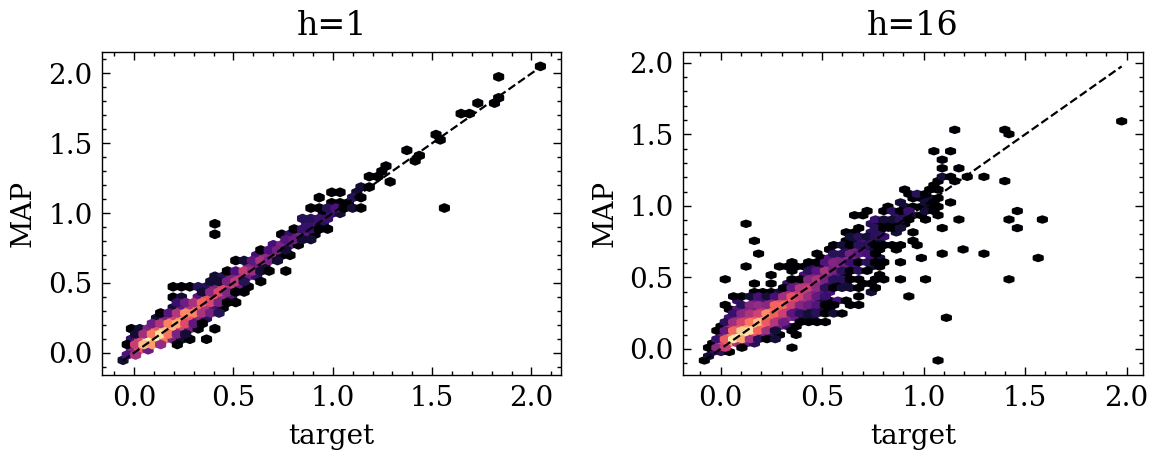

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(6, 2.5), dpi=200)
for j, h in enumerate(hs):
  y = ys[h].numpy().ravel()
  ax[j].hexbin(y, maps[h], gridsize=50, bins="log", cmap="magma")
  ax[j].plot([y.min(), y.max()], [y.min(), y.max()], "k--", linewidth=0.8)
  ax[j].set_title(f"h={h}")
  ax[j].set_xlabel("target")
  ax[j].set_ylabel("MAP")
plt.tight_layout()

## Trace examples

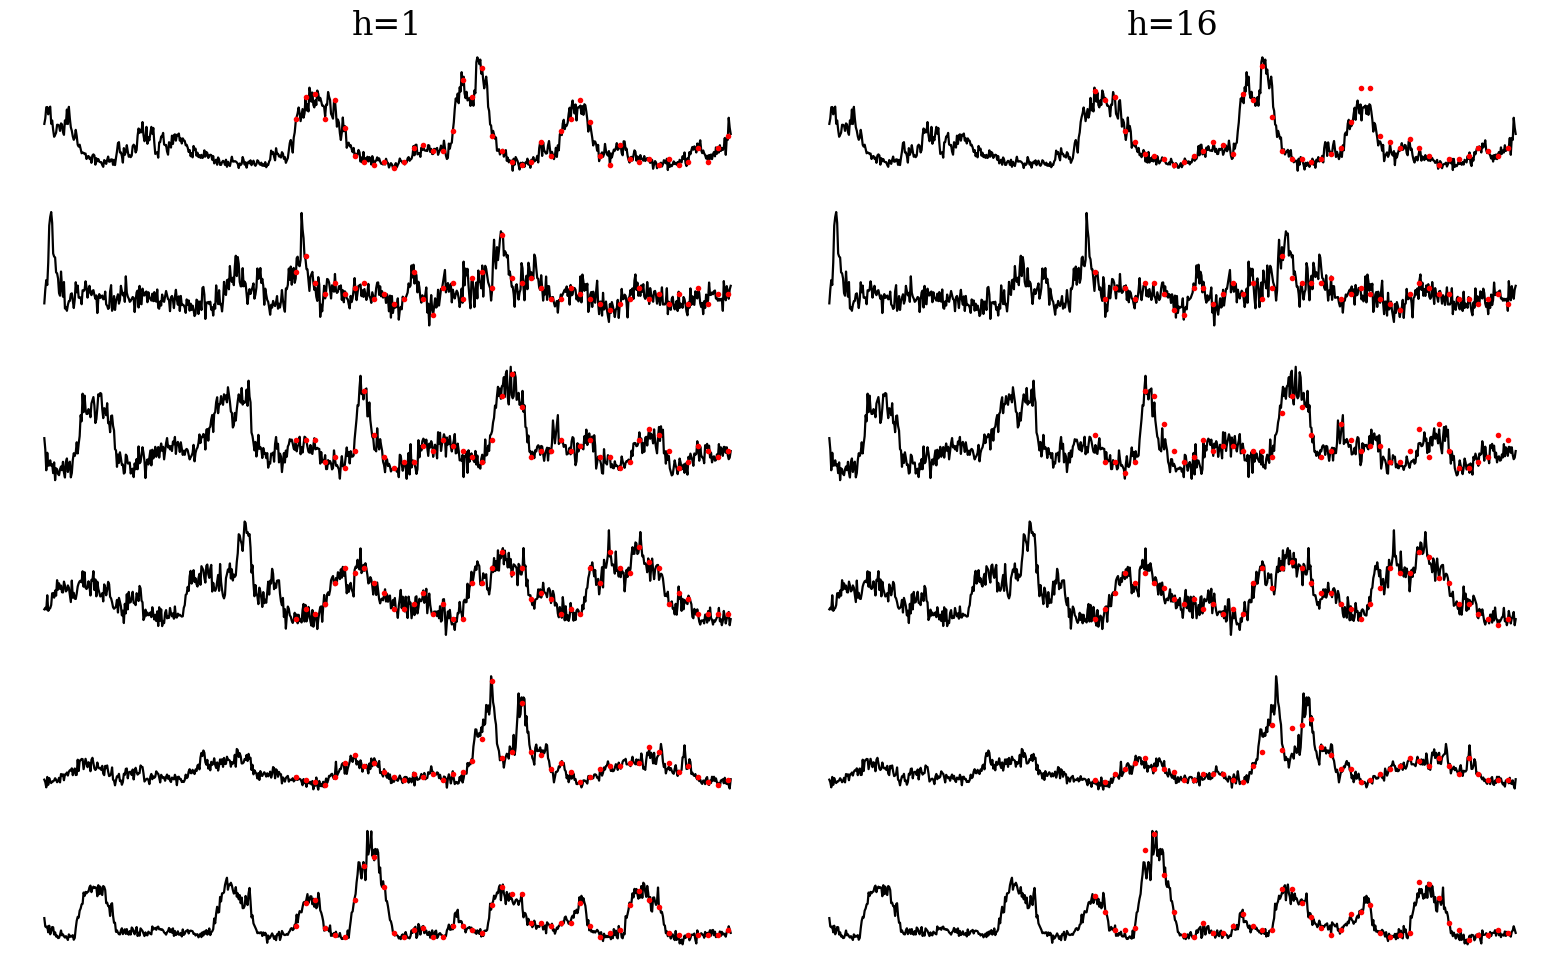

In [11]:
fig, ax = plt.subplots(6, 2, figsize=(8, 5), dpi=200, sharex=True)
for j, h in enumerate(hs):
  pm = maps[h].reshape(len(st), aa.shape[1])
  ti = st + c + h - 1
  q = ti < 700
  for i in range(6):
    ax[i, j].plot(aa[:700, i], "k", linewidth=0.8)
    ax[i, j].plot(ti[q], pm[q, i], "r.", markersize=2)
    ax[i, j].axis("off")
  ax[0, j].set_title(f"h={h}")
plt.tight_layout()

## Result

All bucketed 256-step contexts were unique. Self-lookup is therefore 100% by construction. Exact-context NPE improves on last value but does not reach the lookup ceiling: MAE 0.0199/0.0313 and bucket accuracy 0.491/0.396 at $h=1/16$. This is a memorisation result, not held-out prediction.

## Short contexts

Bucket recurrence over all active-TL trace positions.

In [12]:
cs = (1, 2, 4, 8, 16)
k = 32
rows, groups = [], {}
for c0 in cs:
  tt = np.arange(c0, len(aa) - k + 1)
  z = np.stack([aa[t - c0:t] for t in tt])
  xb = bidx(z.transpose(0, 2, 1).reshape(-1, c0)).astype(np.uint8)
  _, inv, n = np.unique(xb, axis=0, return_inverse=True, return_counts=True)
  rep = np.flatnonzero(n > 1)
  rows.append((c0, len(xb), len(rep), int(n[rep].sum()), int(n.max())))
  if len(rep):
    g = rep[np.argmax(n[rep])]
    groups[c0] = tt, np.flatnonzero(inv == g), int(n[g])
short = pd.DataFrame(rows, columns=["c", "contexts", "repeated buckets", "contexts in repeats", "max count"])
short

,c,contexts,repeated buckets,contexts in repeats,max count
0,1,112440,72,112433,17744
1,2,112410,785,112084,5101
2,4,112350,7998,100354,666
3,8,112230,6749,17067,26
4,16,111990,0,0,1


### Trace examples

Most frequent repeated bucket per context length; context in black, following 32 samples in red.

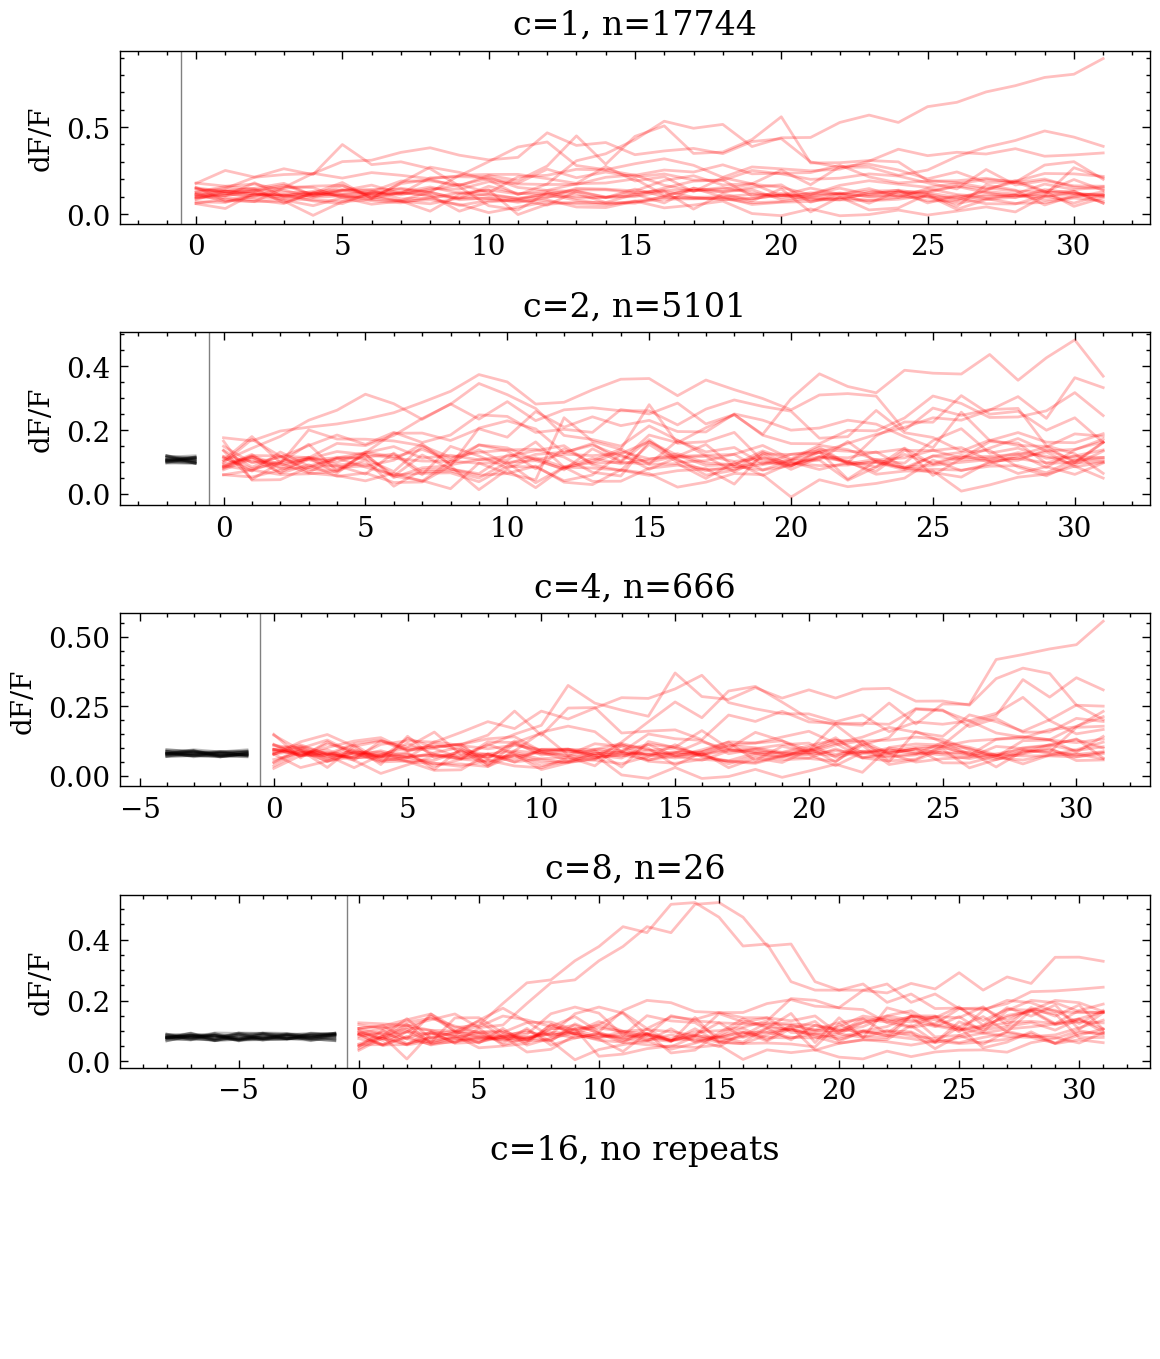

In [ ]:
fig, ax = plt.subplots(len(cs), 1, figsize=(6, 7), dpi=200)
for j, c0 in enumerate(cs):
  if c0 not in groups:
    ax[j].set_title(f"c={c0}, no repeats")
    ax[j].axis("off")
    continue
  tt, q, n = groups[c0]
  q = q[np.linspace(0, len(q) - 1, min(20, len(q))).astype(int)]
  for v in q:
    i, ni = divmod(v, aa.shape[1])
    t = tt[i]
    ax[j].plot(np.arange(-c0, 0), aa[t - c0:t, ni], "k", alpha=0.25)
    ax[j].plot(np.arange(k), aa[t:t + k, ni], "r", alpha=0.25)
  ax[j].axvline(-0.5, color="0.5", linewidth=0.5)
  ax[j].set_title(f"c={c0}, n={n}")
  ax[j].set_ylabel("dF/F")
ax[-1].set_xlabel("time")
plt.tight_layout()

### Result

Bucketed contexts were non-unique for $c=1,2,4,8$ and unique for $c=16$.